# AI512: Artificial Intelligence
# Lab 1 — Intelligent Agents
### Building, Testing, and Comparing Rational Agents in the Vacuum World


**Objective:** Build and evaluate different agent architectures (Simple Reflex, Model-Based, and Goal-Based) in a simulated Vacuum World.

## Setup

import the required libraries

In [40]:
from __future__ import annotations
import random
from collections import deque
from typing import Any, Dict, List, Tuple, FrozenSet, Optional
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
import numpy as np

random.seed(2026)

## Part 1 — Agents, Environments, and the Agent Function

Core concepts:
- An **agent** perceives its **environment** through **sensors** and acts upon it through **actuators**.
- A **percept** is one item the agent senses at an instant; a **percept sequence** is the full history of everything perceived so far.
- The **agent function** is the abstract mathematical mapping from every possible percept sequence to an action.
- The **agent program** is the concrete, finite piece of code that *implements* the agent function.

### Code Architecture Explanation
Below are the main classes we will reuse:
1. **`Agent` class:** This represents the AI. It has a `program()` method where the "thinking" happens. It takes a `percept` as input and returns an `action` as a string.
2. **`Environment` class:** This represents the world. It provides the `percept()` to the agent, receives the chosen action, and updates the world state via `execute_action()`.

The standard AI loop implicitly runs as: `percept` → `program` → `action` → `environment update` → `repeat.`

### Abstract Base Classes
Before we build specific vacuum cleaners, we need to define the fundamental architecture of an AI system. We do this using **Abstract Base Classes (ABCs)**.

**1. The `Agent` Class (The Brain)**
This class is isolated from the world. It only knows what its sensors tell it.
* **`percept_history`**: A list acting as the agent's memory.
* **`program(percept)`**: The core decision-making logic. Because this is marked with `@abstractmethod`, Python forces every future agent we build to write its own custom version of this function.
* **`act(percept)`**: The internal processor. It receives a percept, logs it into memory, and triggers the `program()` to calculate the next action.

**2. The `Environment` Class (The Physics Engine)**
This acts as the simulated universe. It tracks the true state of the world and enforces the rules.
* **`percept()`**: The sensors. It filters the true world state and hands the agent only what it is allowed to see.
* **`execute_action()`**: The actuators. It takes the agent's chosen action and updates the world (e.g., moving coordinates, removing dirt).
* **`step()`**: The **Sense → Think → Act** loop. This single function bridges the two classes together: it grabs the percept, feeds it to the agent's `act()` method, and applies the resulting action to the world.

In [41]:
class Agent(ABC):
    """Abstract base class."""

    def __init__(self, name: str = "Agent"):
        self.name = name
        self.percept_history: List[Any] = []
        self.performance: int = 0   # running score under the environment's performance measure

    @abstractmethod
    def program(self, percept: Any) -> str:
        """The agent PROGRAM: current percept -> action. This is the only
        method every agent subclass must implement."""
        raise NotImplementedError

    def act(self, percept: Any) -> str:
        self.percept_history.append(percept)
        return self.program(percept)

    def __repr__(self):
        return f"<{self.name} perf={self.performance}>"


class Environment(ABC):
    """Base class for a task environment."""

    @abstractmethod
    def percept(self, agent: Agent) -> Any:
        """What does `agent` currently sense?"""
        ...

    @abstractmethod
    def execute_action(self, agent: Agent, action: str) -> None:
        """Apply `action` to the environment on behalf of `agent`"""
        ...

    @abstractmethod
    def is_done(self) -> bool:
        """Has the environment reached a terminal condition?"""
        ...

    def step(self, agent: Agent) -> None:
        p = self.percept(agent)
        a = agent.act(p)
        self.execute_action(agent, a)

    def run(self, agent: Agent, steps: int) -> int:
        """Run the sense-think-act loop for up to `steps` ticks. Returns final performance."""
        for _ in range(steps):
            if self.is_done():
                break
            self.step(agent)
        return agent.performance

## Part 2 — PEAS Practice

Before writing agent code, the **first step is always to specify the task environment** using a **PEAS** description:
- **P**erformance measure
- **E**nvironment
- **A**ctuators
- **S**ensors



> **Agent type:** An autonomous **quadcopter drone** that delivers small packages between a warehouse and residential addresses in a mid-sized city, operating outdoors in all weather short of a hurricane warning.

In [42]:
peas_answer = {
    "performance_measure": [
        "Maximizes percentage of packages delivered on time",
        "Minimizes battery consumption per delivery",
        "Minimizes delivery failures"

    ],
    "environment": [
        "Dynamic weather conditions (wind, rain)",
        "warehouse ,delivery locations",
        "Dynamic traffic, obstacles"

    ],
    "actuators": [
        "Four independent propellers/motors",
        "Motor speed controls",
        "Package release mechanism",
        "Landing mechanism"

    ],
    "sensors": [
        "GPS receiver",
        "obstacle detection sensor",
        "camera",
        "battery sensors"

    ],
}



# Showcase the PEAS attributes
print("\n" + "="*90)
print(f"{' PEAS CLASSIFICATION: AUTONOMOUS DELIVERY ROBOT ':^90}")
print("="*90)

for key, values in peas_answer.items():
    display_key = key.replace('_', ' ').title()
    print(f"\n [ ] {display_key}")
    print("-" * 90)
    for idx, value in enumerate(values, 1):
        print(f"    {idx}. {value}")
print("\n" + "="*90)


                      PEAS CLASSIFICATION: AUTONOMOUS DELIVERY ROBOT                      

 [ ] Performance Measure
------------------------------------------------------------------------------------------
    1. Maximizes percentage of packages delivered on time
    2. Minimizes battery consumption per delivery
    3. Minimizes delivery failures

 [ ] Environment
------------------------------------------------------------------------------------------
    1. Dynamic weather conditions (wind, rain)
    2. warehouse ,delivery locations
    3. Dynamic traffic, obstacles

 [ ] Actuators
------------------------------------------------------------------------------------------
    1. Four independent propellers/motors
    2. Motor speed controls
    3. Package release mechanism
    4. Landing mechanism

 [ ] Sensors
------------------------------------------------------------------------------------------
    1. GPS receiver
    2. obstacle detection sensor
    3. camera
    4. battery

## Part 3 — Environment Properties Practice

We have seven dimensions for classifying task environments.

| Dimension | Possible labels |
|---|---|
| Observable | `Fully` / `Partially` / `Unobservable` |
| Agents | `Single` / `Multi` |
| Deterministic | `Deterministic` / `Nondeterministic` / `Stochastic` |
| Episodic | `Episodic` / `Sequential` |
| Static | `Static` / `Dynamic` / `Semidynamic` |
| Discrete | `Discrete` / `Continuous` |
| Known | `Known` / `Unknown` |


Classify the environments below.
1. **Warehouse package-sorting robot**
2. **Automated high-frequency stock-trading agent** — buys/sells shares on a live exchange based on market data feeds.
3. **Smart home thermostat** — adjusts heating/cooling based on temperature sensors and an occupancy schedule.

In [43]:
env_classification = {
    "warehouse_sorting_robot": {

        "observable": "Fully",
        "agents": "Single",
        "deterministic": "Deterministic",
        "episodic": "Episodic",
        "static": "Static",
        "discrete": "Discrete",
        "known": "Known",

    },
    "stock_trading_agent": {

        "observable": "Partially",
        "agents": "Multi",
        "deterministic": "Stochastic",
        "episodic": "Sequential",
        "static": "Dynamic",
        "discrete": "Discrete",
        "known": "Known",
    },
    "smart_thermostat": {

        "observable": "Partially",
        "agents": "Single",
        "deterministic": "Stochastic",
        "episodic": "Sequential",
        "static": "Dynamic",
        "discrete": "Continuous",
        "known": "Known",

    },
}


print("\n" + "=" * 90)
print(f"{' ENVIRONMENT CLASSIFICATIONS ':^90}")
print("=" * 90)

for env_name, props in env_classification.items():
    title = env_name.replace("_", " ").title()
    print(f"\n [+] {title}")
    print("-" * 90)
    for key, value in props.items():
        display_key = key.replace("_", " ").title()
        display_val = value if value not in (None, "") else "[UNFILLED]"
        print(f"  * {display_key:<31}: {display_val}")
print("\n" + "=" * 90)


                               ENVIRONMENT CLASSIFICATIONS                                

 [+] Warehouse Sorting Robot
------------------------------------------------------------------------------------------
  * Observable                     : Fully
  * Agents                         : Single
  * Deterministic                  : Deterministic
  * Episodic                       : Episodic
  * Static                         : Static
  * Discrete                       : Discrete
  * Known                          : Known

 [+] Stock Trading Agent
------------------------------------------------------------------------------------------
  * Observable                     : Partially
  * Agents                         : Multi
  * Deterministic                  : Stochastic
  * Episodic                       : Sequential
  * Static                         : Dynamic
  * Discrete                       : Discrete
  * Known                          : Known

 [+] Smart Thermostat
----------

## Part 4 — The Vacuum-World Environment

Here we generalize the 2-square vacuum world to an **N × M grid**. This single `VacuumEnvironment` class will support *every* agent architecture we build because the amount of information it reveals is controlled by `sensor_mode`:

| `sensor_mode` | Percept returned | Used for |
|---|---|---|
| `"full"` | `(location, status)` | Simple reflex agent (fully observable) |
| `"dirt_only"` | `status` | Randomized reflex agent (no location sensor at all) |
| `"dirt_bump"` | `(status, bump)` | Model-based reflex agent (location must be *inferred*) |
| `"full_map"` | `(location, status, dirty_set)` | Goal-based agents (fully observable, global map) |

**Performance measure**: Every time step, the agent earns **+1 point for every currently-clean square**. An optional `move_penalty` can also be charged per successful move to illustrate movement efficiency.


### Building the World: The Vacuum Environment
Now we translate our generic `Environment` blueprint into a specific **N × M Grid World**.

This single environment class is designed to support *all* of our upcoming agent architectures. By changing the `sensor_mode` parameter. Controlling what the sensors reveal is a crucial PEAS design decision that dictates which AI architectures can succeed.

* **`"full"`**: The agent sees its exact (X, Y) coordinates and the dirt status. (Fully observable)
* **`"dirt_only"`**: The agent only knows if it is standing on dirt. (Partially observable)
* **`"dirt_bump"`**: The agent knows if it is on dirt, and if its *last* move hit a wall. (Partially observable)
* **`"full_map"`**: The agent sees its coordinates, current status, and the exact locations of all dirt on the entire grid. (Fully observable)

**The Physics:** The `execute_action()` method handles the grid physics. If an agent tries to move out of bounds, `_clamped_move()` stops it, and a `bump` flag is triggered. Every tick, the agent's performance score increases by +1 for every clean square on the board.

In [44]:
class VacuumEnvironment(Environment):
    ACTIONS = ["Up", "Down", "Left", "Right", "Suck", "NoOp"]

    def __init__(self, width=2, height=1, dirt_prob=0.5, move_penalty=0,
                 respawn_prob=0.0, sensor_mode="full", max_steps=1000, seed=None):
        if seed is not None:
            random.seed(seed)
        self.width = width
        self.height = height

        # Dictionary mapping (r, c) tuples to boolean values (True = Dirty).
        self.dirt: Dict[Tuple[int, int], bool] = {(r, c): random.random() < dirt_prob for r in range(self.height) for c in range(self.width)}

        self.agent_location: Dict[Agent, Tuple[int, int]] = {}
        self.move_penalty = move_penalty
        self.respawn_prob = respawn_prob
        self.sensor_mode = sensor_mode
        self.time_step = 0
        self.max_steps = max_steps
        self._last_bump: Dict[Agent, bool] = {}

    def add_agent(self, agent: Agent, location=(0, 0)):
        self.agent_location[agent] = location
        self._last_bump[agent] = False

    def percept(self, agent: Agent):
        loc = self.agent_location[agent]

        # Determine the status of the agent's current location.
        status = "Dirty" if self.dirt[loc] else "Clean"

        if self.sensor_mode == "full":
            return (loc, status)
        elif self.sensor_mode == "dirt_only":
            return status
        elif self.sensor_mode == "dirt_bump":
            return (status, self._last_bump[agent])
        elif self.sensor_mode == "full_map":
            dirty_set = frozenset(l for l, d in self.dirt.items() if d)
            return (loc, status, dirty_set)
        else:
            raise ValueError(f"unknown sensor_mode: {self.sensor_mode}")

    def _clamped_move(self, loc, dr, dc):
        r, c = loc

        # Calculate new coordinates and clamp them so the agent doesn't leave the grid.
        nr = max(0, min(self.height - 1, r + dr))
        nc = max(0, min(self.width - 1, c + dc))

        return (nr, nc)

    def execute_action(self, agent: Agent, action: str):
        loc = self.agent_location[agent]
        self._last_bump[agent] = False  # reset each tick;

        if action == "Suck":
            # Implement the "Suck" action.

            if self.dirt[loc]:
              self.dirt[loc] = False

        elif action in ("Up", "Down", "Left", "Right"):
            deltas = {"Up": (-1, 0), "Down": (1, 0), "Left": (0, -1), "Right": (0, 1)}
            new_loc = self._clamped_move(loc, *deltas[action])

            # Handle movement results.
            if new_loc != loc:
                self.agent_location[agent] = new_loc
                if self.move_penalty > 0:
                    agent.performance -= self.move_penalty
            else:
                self._last_bump[agent] = True

        elif action == "NoOp":
            pass
        else:
            raise ValueError(f"Unknown action: {action}")

        # Update the performance measure.
        agent.performance += sum(1 for is_dirty in self.dirt.values() if not is_dirty)

        if self.respawn_prob > 0:
            for l in self.dirt:
                if not self.dirt[l] and random.random() < self.respawn_prob:
                    self.dirt[l] = True

        self.time_step += 1

    def is_done(self):
        return self.time_step >= self.max_steps

In [45]:
# Sanity check: recreate the 2-square world and verify
# a trivial "always suck, else move right" agent cleans it.

class _AlwaysSuckDemo(Agent):
    def program(self, percept):
        loc, status = percept

        # Implement the trivial agent logic.
        return "Suck" if status == "Dirty" else "Right"


# Instantiate the VacuumEnvironment and Agent
demo_env = VacuumEnvironment(width=2, height=1, dirt_prob=1.0, sensor_mode="full", seed=0, max_steps=4)
demo_agent = _AlwaysSuckDemo("demo")

# Run the sanity check
if demo_env is not None and demo_agent is not None:
    demo_env.add_agent(demo_agent, (0, 0))
    print("Before:", demo_env.dirt)

    demo_env.run(demo_agent, 4)
    print("After: ", demo_env.dirt)

    # verify that all values in demo_env.dirt are False.
    assert not any(demo_env.dirt.values())

    print("Environment sanity check passed")
else:
    print("Sanity check could not be completed.")

Before: {(0, 0): True, (0, 1): True}
After:  {(0, 0): False, (0, 1): False}
Environment sanity check passed


## Part 5 — Simple Reflex Agents

A **simple reflex agent** chooses its action using **only the current percept**, ignoring history entirely. This works *only if the environment is fully observable*.

### 5.1 — Fully observable case
Below is a simple reflex agent for our generalized N×M grid. Because `sensor_mode="full"` gives it `(location, status)` every tick, it never needs memory: it computes "what to do" from the current percept alone using a boustrophedon ("lawn-mower") rule.

### Agent 1: The Simple Reflex Agent
A **simple reflex agent** operates strictly on **Condition-Action rules** (If X, then Y). It has zero memory and completely ignores percept history.

Because our `sensor_mode="full"` provides the agent with its exact `(row, col)` location and dirt status every single tick, memory isn't necessary. The agent can calculate its next move purely from the current percept.

**The Strategy:** We implement a \"boustrophedon\" (lawn-mower) sweep. It moves right along even rows, drops down, and moves left along odd rows. If it sees dirt, it sucks it up.

In [46]:
class SimpleReflexVacuumAgent(Agent):
    """Fully observable: percept = (location, status). No internal memory needed."""

    def __init__(self, width, height):
        super().__init__("SimpleReflexVacuumAgent")
        self.width = width
        self.height = height

    def program(self, percept):
        loc, status = percept
        if status == "Dirty":
            return "Suck"
        r, c = loc
        # sweep right along even rows, left along odd rows
        if r % 2 == 0:
            return "Right" if c < self.width - 1 else "Down"
        else:
            return "Left" if c > 0 else "Down"

sr_env = VacuumEnvironment(width=4, height=3, dirt_prob=0.5, sensor_mode="full", seed=3, max_steps=40)
sr_agent = SimpleReflexVacuumAgent(4, 3)
sr_env.add_agent(sr_agent, (0, 0))
steps = 0
while any(sr_env.dirt.values()) and steps < 40:
    sr_env.step(sr_agent)
    steps += 1
print(f"Fully clean after {steps} steps: {not any(sr_env.dirt.values())}")
print("Final performance:", sr_agent.performance)

Fully clean after 18 steps: True
Final performance: 154


### 5.2 — Partially observable case

Now we remove the location sensor (`sensor_mode="dirt_only"`). A *deterministic* simple reflex agent gets stuck forever if it starts in the wrong square (e.g., "always move Right" fails if the dirt is to the Left). The fix: **randomize**.


### Agent 2: Handling Partial Observability with Randomization
What happens if we blindfold the simple reflex agent? We change the environment to `sensor_mode="dirt_only"`. Now, the agent has no idea where it is, and it still has no memory.

If we hard-code a deterministic rule (e.g., "Always move Right"), the agent will instantly fail if it starts on the right edge of the grid while the dirt is on the left. It will just slam into the wall forever.

**The Fix:** When an environment is partially observable and an agent lacks memory, **randomization** is often the only way to guarantee that it will eventually break out of infinite loops and explore the whole space.

In [47]:
class RandomizedReflexVacuumAgent(Agent):
    """Only has a dirt sensor (sensor_mode='dirt_only'). No location, no memory."""

    def program(self, percept):

        # Implement the randomized logic

        if percept == "Dirty":
          return "Suck"
        return random.choice(["Left", "Right"])

In [48]:
# Self-check: compare a DETERMINISTIC agent against the randomized agent.

class AlwaysRightAgent(Agent):
    def program(self, percept):
        # Deterministic failure state
        return "Suck" if percept == "Dirty" else "Right"

def steps_to_clean(agent_factory, seed, max_steps=200):
    env = VacuumEnvironment(width=2, height=1, dirt_prob=1.0, sensor_mode="dirt_only",
                             seed=seed, max_steps=max_steps)
    agent = agent_factory()
    env.add_agent(agent, (0, 0))
    steps = 0

    # Evaluation Loop
    while any(env.dirt.values()) and steps < max_steps:
        env.step(agent)
        steps += 1

    return steps if not any(env.dirt.values()) else None

# Analytics calculations
deterministic_failures = sum(1 for i in range(100) if steps_to_clean(AlwaysRightAgent, i) is None)
randomized_results = [steps_to_clean(lambda: RandomizedReflexVacuumAgent(), i) for i in range(100)]
randomized_failures = randomized_results.count(None)
randomized_avg_steps = sum(r for r in randomized_results if r is not None) / (100 - randomized_failures)

if None not in (deterministic_failures, randomized_failures, randomized_avg_steps):
    print(f"Deterministic 'always Right' agent: stuck forever in {deterministic_failures}/100 runs")
    print(f"Randomized agent: stuck forever in {randomized_failures}/100 runs, "
          f"avg steps to finish = {randomized_avg_steps:.2f}")

    assert randomized_failures == 0, "randomized agent should always eventually finish"
    assert 1.0 <= randomized_avg_steps <= 6.0, "sanity range from the text's ~2-step claim"
    print("RandomizedReflexVacuumAgent self-check PASSED")
else:
    print("Comparison could not be completed.")

Deterministic 'always Right' agent: stuck forever in 0/100 runs
Randomized agent: stuck forever in 0/100 runs, avg steps to finish = 4.20
RandomizedReflexVacuumAgent self-check PASSED


## Part 6 — Model-Based Reflex Agent

To handle partial observability cleanly, a **model-based reflex agent** maintains **internal state**, updated every tick using:
- a **transition model** — "what do my actions do?"
- a **sensor model** — "how does the world state show up in my percepts?" (e.g., a wall bump means the move failed)



### Agent 3: The Model-Based Reflex Agent
Instead of relying on random luck in a partially observable world, a **model-based agent** uses memory to maintain an internal representation (a model) of the unseen world.

Given `sensor_mode="dirt_bump"`, the agent cannot see its coordinates. However, it *can* deduce them by keeping track of its own actions.
* **The Transition Model:** \"If I was at (0,0) and moved Right, I am probably now at (0,1).\"
* **The Sensor Model:** \"If my sensors return a `bump`, my last move failed, so I am still at (0,0).\"

By updating `self.believed_loc` every tick using `_apply_transition()`, the agent successfully maps the unseen world and executes a perfect lawn-mower sweep without ever actually \"seeing\" its coordinates.

In [49]:
class ModelBasedVacuumAgent(Agent):
    """Partially observable NxM world; percept = (status, bump). No location sensor."""

    def __init__(self, width, height):
        super().__init__("ModelBasedVacuumAgent")
        self.width = width
        self.height = height
        self.believed_loc: Tuple[int, int] = (0, 0)   # internal MODEL of where we are
        self.direction: str = "Right"                 # current sweep direction
        self.done_sweeping: bool = False
        self.last_action: Optional[str] = None

    def _apply_transition(self, bump: bool) -> None:
        """Transition & Sensor Model UPDATE-STATE step."""
        if self.last_action in ("Up", "Down", "Left", "Right"):
            if not bump:
                r, c = self.believed_loc
                if self.last_action == "Up": r -= 1
                elif self.last_action == "Down": r += 1
                elif self.last_action == "Left": c -= 1
                elif self.last_action == "Right": c += 1
                self.believed_loc = (r, c)

    def program(self, percept):
        status, bump = percept
        self._apply_transition(bump)

        if status == "Dirty":
            self.last_action = "Suck"
            return "Suck"

        if self.done_sweeping:
            self.last_action = "NoOp"
            return "NoOp"

        # Implement the boustrophedon decision

        if self.last_action in ("Left", "Right") and bump:
            if self.believed_loc[0] >= self.height - 1:
                self.done_sweeping = True
                self.last_action = "NoOp"
                return "NoOp"
            else:
                self.direction = "Left" if self.direction == "Right" else "Right"
                self.last_action = "Down"
                return "Down"


        # Default movement logic if no bump occurred
        self.last_action = self.direction
        return self.direction

In [50]:
# Self-check: verify the internal belief location matches the TRUE location

def run_model_based_and_check(width, height, dirt_prob, seed, max_steps=500):
    env = VacuumEnvironment(width=width, height=height, dirt_prob=dirt_prob,
                             sensor_mode="dirt_bump", seed=seed, max_steps=max_steps)
    agent = ModelBasedVacuumAgent(width, height)
    env.add_agent(agent, (0, 0))
    steps = 0

    # Model-Based Evaluation Loop
    while not env.is_done():
        if steps > 0 and not any(env.dirt.values()):
            break

        actual_loc = env.agent_location[agent]
        p = env.percept(agent)
        a = agent.act(p)

        assert agent.believed_loc == actual_loc, f"Belief {agent.believed_loc} != Actual {actual_loc}"

        env.execute_action(agent, a)
        steps += 1

    return not any(env.dirt.values()), steps

test_grids = [(4, 3, 0.5, 1), (5, 5, 0.3, 7), (3, 3, 0.9, 42), (1, 5, 0.5, 3), (5, 1, 0.5, 9), (1, 1, 1.0, 2)]
for (w, h, p, seed) in test_grids:
    clean, steps = run_model_based_and_check(w, h, p, seed)
    if steps == 0:
        print(f"grid={w}x{h} seed={seed}: skipped (loop not implemented)")
        continue
    print(f"grid={w}x{h} seed={seed}: fully_clean={clean}  steps={steps}")
    assert clean, f"agent failed to fully clean the {w}x{h} grid (seed={seed})"

print("ModelBasedVacuumAgent self-check PASSED")

grid=4x3 seed=1: fully_clean=True  steps=20
grid=5x5 seed=7: fully_clean=True  steps=39
grid=3x3 seed=42: fully_clean=True  steps=19
grid=1x5 seed=3: fully_clean=True  steps=6
grid=5x1 seed=9: fully_clean=True  steps=8
grid=1x1 seed=2: fully_clean=True  steps=1
ModelBasedVacuumAgent self-check PASSED


## Part 7 — Goal-Based Agent: BFS Search

A **goal-based agent** uses a model of the world and searches for a sequence of actions that achieves its goal. Here we switch to `sensor_mode="full_map"`, which makes the agent **fully observable** (it can see its exact location *and* every currently-dirty cell globally).



### Agent 4: The Goal-Based Agent (Search & Planning)
Reflex agents just react. A **goal-based agent** looks into the future. It identifies a specific objective, simulates different sequences of actions to see which one achieves that objective, and then executes that plan.

We grant this agent `sensor_mode="full_map"`. It can see every piece of dirt on the grid.
1. **Formulate Goal:** Find the nearest piece of dirt using Manhattan distance (`choose_target`).
2. **Search:** Use a Breadth-First Search (`bfs_path`) algorithm to explore the grid mathematically and find the shortest path to that dirt.
3. **Execute:** Save that path to a queue (`self.plan`) and execute it one step at a time. Once the queue is empty, find the next target and repeat.

In [51]:
class GoalBasedVacuumAgent(Agent):
    """Fully observable: percept = (location, status, dirty_set)."""

    def __init__(self, width, height, name="GoalBasedVacuumAgent"):
        super().__init__(name)
        self.width = width
        self.height = height
        self.plan: deque = deque()

    @staticmethod
    def bfs_path(start, goal, width, height) -> List[str]:
        """Breadth-first search over the grid graph."""
        if start == goal: return []

        queue = deque([(start, [])])
        visited = {start}
        directions = { "Up": (-1, 0), "Down": (1, 0), "Left": (0, -1), "Right": (0, 1) }

        while queue:
            (r, c), path = queue.popleft()
            if (r, c) == goal:
                return path

            for action, (dr, dc) in directions.items():
                nr, nc = r + dr, c + dc
                if 0 <= nr < height and 0 <= nc < width and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    queue.append(((nr, nc), path + [action]))
        return []

    def choose_target(self, loc, dirty_set):
        """Finds the nearest dirty cell by Manhattan distance."""
        return min(dirty_set, key=lambda g: abs(g[0] - loc[0]) + abs(g[1] - loc[1]))

    def program(self, percept):
        loc, status, dirty_set = percept


        if status == "Dirty":
            self.plan.clear()
            return "Suck"

        if self.plan:
            return self.plan.popleft()

        if not dirty_set:
            return "NoOp"

        target = self.choose_target(loc, dirty_set)
        path = self.bfs_path(loc, target, self.width, self.height)
        self.plan.extend(path)
        return self.plan.popleft() if self.plan else "NoOp"

In [52]:
# Self-check

path = GoalBasedVacuumAgent.bfs_path((0, 0), (2, 3), 5, 5)

if path:
    assert len(path) == 5, f"expected a 5-move Manhattan-shortest path, got {path}"
    assert path.count("Down") == 2 and path.count("Right") == 3

def run_goal_based_and_check(width, height, dirt_prob, seed, max_steps=500):
    env = VacuumEnvironment(width=width, height=height, dirt_prob=dirt_prob,
                             sensor_mode="full_map", seed=seed, max_steps=max_steps)
    agent = GoalBasedVacuumAgent(width, height)
    env.add_agent(agent, (0, 0))
    steps = 0

    # Evaluation Loop
    while not env.is_done() and any(env.dirt.values()):
        env.step(agent)
        steps += 1

    return not any(env.dirt.values()), steps

test_grids = [(4, 3, 0.5, 1), (6, 6, 0.3, 7), (3, 3, 0.9, 42), (1, 6, 0.4, 3)]
for (w, h, p, seed) in test_grids:
    clean, steps = run_goal_based_and_check(w, h, p, seed)
    if steps == 0:
        print(f"grid={w}x{h} seed={seed}: skipped")
        continue
    print(f"grid={w}x{h} seed={seed}: fully_clean={clean}  steps={steps}")
    assert clean, "agent failed to fully clean the grid"

if path and steps > 0:
    print("GoalBasedVacuumAgent self-check PASSED")

grid=4x3 seed=1: fully_clean=True  steps=16
grid=6x6 seed=7: fully_clean=True  steps=44
grid=3x3 seed=42: fully_clean=True  steps=18
grid=1x6 seed=3: fully_clean=True  steps=8
GoalBasedVacuumAgent self-check PASSED


## Part 8 — Benchmarking & Comparison

Now we'll run **each** architecture on its matching `sensor_mode` over many random grids (fixed size, varying random seeds), and compare the *distribution* of final performance scores.


SimpleReflex
(full obs) mean=  329.57  std= 29.91
ModelBased
(dirt+bump) mean=  319.83  std= 32.98
GoalBased
(full map)   mean=  346.70  std= 25.91


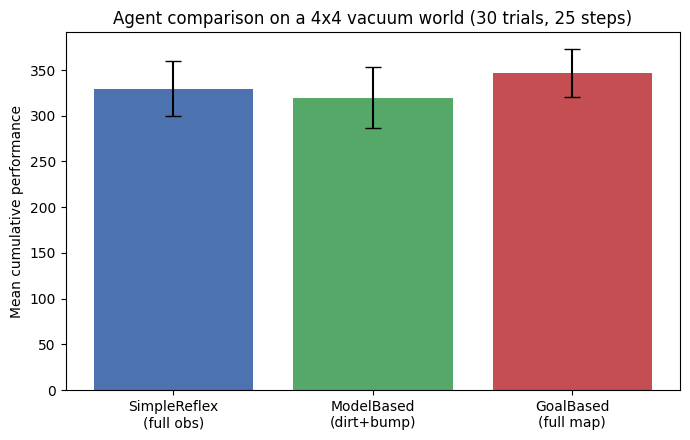

In [53]:
def bench(agent_factory, env_factory, steps, trials):
    scores = []
    for i in range(trials):
        env = env_factory(i)
        agent = agent_factory()
        env.add_agent(agent, (0, 0))
        scores.append(env.run(agent, steps))
    return scores

W, H, DIRT_PROB, STEPS, TRIALS = 4, 4, 0.4, 25, 30

results = {}

results["SimpleReflex\n(full obs)"] = bench(
    lambda: SimpleReflexVacuumAgent(W, H),
    lambda i: VacuumEnvironment(W, H, DIRT_PROB, sensor_mode="full", seed=i, max_steps=STEPS),
    STEPS, TRIALS)

results["ModelBased\n(dirt+bump)"] = bench(
    lambda: ModelBasedVacuumAgent(W, H),
    lambda i: VacuumEnvironment(W, H, DIRT_PROB, sensor_mode="dirt_bump", seed=i, max_steps=STEPS),
    STEPS, TRIALS)

results["GoalBased\n(full map)"] = bench(
    lambda: GoalBasedVacuumAgent(W, H),
    lambda i: VacuumEnvironment(W, H, DIRT_PROB, sensor_mode="full_map", seed=i, max_steps=STEPS),
    STEPS, TRIALS)

for name, scores in results.items():
    print(f"{name.strip():22s} mean={np.mean(scores):8.2f}  std={np.std(scores):6.2f}")

names = list(results.keys())
means = [np.mean(results[n]) for n in names]
stds = [np.std(results[n]) for n in names]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(names, means, yerr=stds, capsize=6, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean cumulative performance")
ax.set_title(f"Agent comparison on a {W}x{H} vacuum world ({TRIALS} trials, {STEPS} steps)")
plt.tight_layout()
plt.show()

### Widen the observability gap

The comparison above uses a small, mostly-clean grid, so every architecture has an easy time. Re-run the benchmark with a **larger, dirtier** grid (e.g. `W, H = 8, 8` and `DIRT_PROB = 0.7`) and a **shorter** time budget (e.g. `STEPS = 20`).

In larger grids with shorter time bounds, the Goal-Based Agent's relative advantage grows dramatically. Since it utilizes the full_map sensor mode, it plots optimal paths directly to the nearest dirt, ensuring every action is highly efficient. In contrast, reflex agents rely on blind sweeping or randomization, which wastes their limited step allocations traversing over already-clean tiles.

SimpleReflex
(full obs) mean=  467.63  std= 78.09
ModelBased
(dirt+bump) mean=  464.93  std= 77.91
GoalBased
(full map)   mean=  480.20  std= 79.50


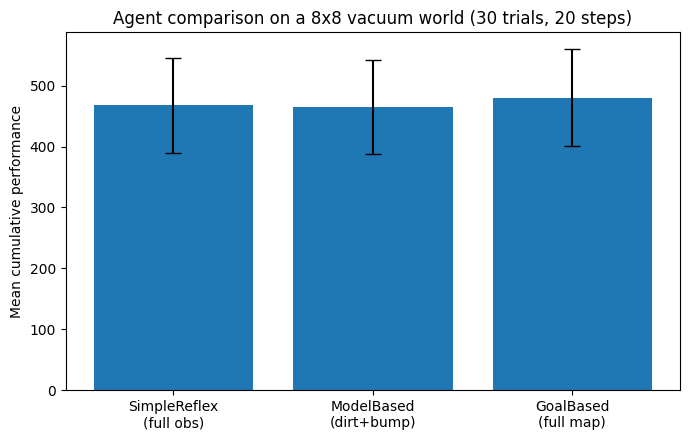

In [54]:


W, H, DIRT_PROB, STEPS, TRIALS = 8, 8, 0.7, 20, 30

results_wide = {}
results_wide["SimpleReflex\n(full obs)"] = bench(
    lambda: SimpleReflexVacuumAgent(W, H),
    lambda i: VacuumEnvironment(W, H, DIRT_PROB, sensor_mode="full", seed=i, max_steps=STEPS),
    STEPS, TRIALS)
results_wide["ModelBased\n(dirt+bump)"] = bench(
    lambda: ModelBasedVacuumAgent(W, H),
    lambda i: VacuumEnvironment(W, H, DIRT_PROB, sensor_mode="dirt_bump", seed=i, max_steps=STEPS),
    STEPS, TRIALS)
results_wide["GoalBased\n(full map)"] = bench(
    lambda: GoalBasedVacuumAgent(W, H),
    lambda i: VacuumEnvironment(W, H, DIRT_PROB, sensor_mode="full_map", seed=i, max_steps=STEPS),
    STEPS, TRIALS)

for name, scores in results_wide.items():
    print(f"{name.strip():22s} mean={np.mean(scores):8.2f}  std={np.std(scores):6.2f}")

names = list(results_wide.keys())
means = [np.mean(results_wide[n]) for n in names]
stds = [np.std(results_wide[n]) for n in names]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(names, means, yerr=stds, capsize=6)
ax.set_ylabel("Mean cumulative performance")
ax.set_title(f"Agent comparison on a {W}x{H} vacuum world ({TRIALS} trials, {STEPS} steps)")
plt.tight_layout()
plt.show()